In [4]:
import os 
os.chdir("../")

In [25]:
import pandas as pd
from src.utils.data_tools import find_final_data_bytime
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from typing import List
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def montage_monthly(years_selected: List[str], n_time: str):
    found_data = find_final_data_bytime(years_selected, n_time)
    data = []
    for _, path in found_data:
        df = pd.read_csv(path)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        agg = df.resample('M').sum()
        data.append(agg)

    full_data = pd.concat(data, axis=0)
    months_groups = full_data.groupby(full_data.index)

    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.set_global()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    # Initialize scatter once
    scat = ax.scatter([], [], s=[], c='red')

    def update(frame):
        data = months_groups.get_group(frame)
        if data.empty:
            return scat,

        # Update scatter offsets and sizes
        scat.set_offsets(data[['long_bin', 'lat_bin']].values)
        scat.set_sizes(data['fire_count'] * 2)

        ax.set_title(f"Month {frame.strftime('%Y-%m')}")
        ax.set_xlim(data['long_bin'].min() - 1, data['long_bin'].max() + 1)
        ax.set_ylim(data['lat_bin'].min() - 1, data['lat_bin'].max() + 1)

        return scat,

    ani = FuncAnimation(fig, update, frames=months_groups.groups.keys(), blit=True, repeat=False)
    return HTML(ani.to_jshtml())


In [26]:
montage_monthly(['2022','2023','2024'], '1d')

/tmp/ipykernel_7827/1106475447.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  agg = df.resample('M').sum()
/tmp/ipykernel_7827/1106475447.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  agg = df.resample('M').sum()
/tmp/ipykernel_7827/1106475447.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  agg = df.resample('M').sum()


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (0,)

ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (0,)

<Figure size 1000x500 with 1 Axes>

In [ ]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import cartopy.crs as ccrs

# Example: pick a year
years_selected = ['2022','2023', '2024']

found_data = find_final_data_bytime(years_selected, '1d')
final_data = []

for _, path in found_data:
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    final_data.append(df)
year_data = pd.concat(final_data)
# Aggregate by month
monthly_data = (
    year_data
    .resample('M')
    .sum()
    .reset_index()
)

months = sorted(monthly_data['date'].unique())
cumulative_data = pd.DataFrame(columns=monthly_data.columns)

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_global()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

def update(frame):
    nonlocal cumulative_data
    # take data for this month
    data = monthly_data[monthly_data['date'] == frame]
    cumulative_data = pd.concat([cumulative_data, data])
    cumulative_data['fire_count'] = cumulative_data['fire_count'].fillna(1)

    ax.clear()
    ax.coastlines()
    ax.set_global()
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    ax.scatter(cumulative_data['long_bin'], cumulative_data['lat_bin'],
               s=cumulative_data['fire_count']*2, c='red', alpha=0.6,
               transform=ccrs.PlateCarree())
    ax.set_title(f'Month {frame.strftime("%Y-%m")}')
    ax.set_xlim(year_data['long_bin'].min() - 1, year_data['long_bin'].max() + 1)
    ax.set_ylim(year_data['lat_bin'].min() - 1, year_data['lat_bin'].max() + 1)

ani = FuncAnimation(fig, update, frames=months, repeat=False)
HTML(ani.to_jshtml())


/tmp/ipykernel_7827/952305147.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


In [2]:
import os 
os.chdir('../')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import cartopy.crs as ccrs
from typing import List
from src.utils.data_tools import find_final_data_bytime

def montage_monthly(years_selected: List[str], n_time: str):
    found_data = find_final_data_bytime(years_selected, n_time)
    data = []
    

    for _, path in found_data:
        df = pd.read_csv(path)
        df['date'] = pd.to_datetime(df['date'])
        # Group by month + lat_bin + long_bin
        df['month'] = df['date'].dt.to_period('M')
        agg = (
            df.groupby(['month', 'lat_bin', 'long_bin'])
              .agg({'fire_count':'sum'})
              .reset_index()
        )
        agg['date'] = agg['month'].dt.to_timestamp()
        data.append(agg)

    full_data = pd.concat(data, axis=0)
    months = sorted(full_data['date'].unique())

    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.set_global()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    scat = ax.scatter([], [], s=[], c='red', alpha=0.6, transform=ccrs.PlateCarree())

    def update(frame):
        data = full_data[full_data['date'] == frame]
        if data.empty:
            return scat,

        scat.set_offsets(data[['long_bin', 'lat_bin']].values)
        scat.set_sizes(data['fire_count'] * 2)
        ax.set_title(f"Month {frame.strftime('%Y-%m')}")
        ax.set_xlim(full_data['long_bin'].min() - 1, full_data['long_bin'].max() + 1)
        ax.set_ylim(full_data['lat_bin'].min() - 1, full_data['lat_bin'].max() + 1)
        return scat,

    ani = FuncAnimation(fig, update, frames=months, blit=True, repeat=False)
    return HTML(ani.to_jshtml())


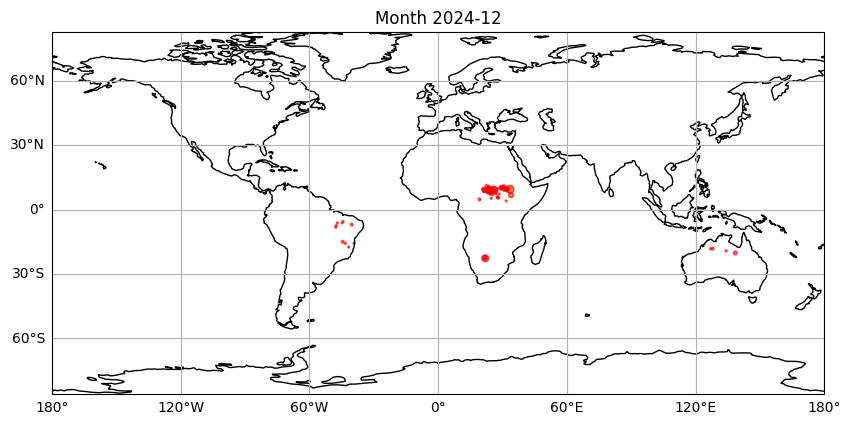

In [4]:
montage_monthly(['2022','2023', '2024'], '1d')